# 01 - Exploratory Data Analysis

Load, clean, and get a feel for the RetailPulse dataset.

In [16]:
import sys; sys.path.append('../src')
import pandas as pd, numpy as np
import matplotlib.pyplot as plt, seaborn as sns
from data_prep import clean_transactions, summarize
sns.set_theme(style='whitegrid'); plt.rcParams['figure.figsize']=(10,5)

In [17]:
# Load raw data (after placing online_retail_II.xlsx in ../data/raw/)
raw = pd.read_excel('../data/raw/online_retail_II.xlsx', sheet_name=None)
df = pd.concat(raw.values(), ignore_index=True)
df = clean_transactions(df)
summarize(df)

{'rows': 805549,
 'customers': 5878,
 'invoices': 36969,
 'first_order': Timestamp('2009-12-01 07:45:00'),
 'last_order': Timestamp('2011-12-09 12:50:00'),
 'total_revenue': np.float64(17743429.18)}

## Shape & missingness

In [18]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 805549 entries, 0 to 805548
Data columns (total 9 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   invoice       805549 non-null  object        
 1   stock_code    805549 non-null  object        
 2   description   805549 non-null  object        
 3   quantity      805549 non-null  int64         
 4   invoice_date  805549 non-null  datetime64[ns]
 5   price         805549 non-null  float64       
 6   customer_id   805549 non-null  int64         
 7   country       805549 non-null  object        
 8   revenue       805549 non-null  float64       
dtypes: datetime64[ns](1), float64(2), int64(2), object(4)
memory usage: 55.3+ MB


,quantity,invoice_date,price,customer_id,revenue
count,805549.000000,805549,805549.000000,805549.000000,805549.000000
mean,13.290522,2011-01-02 10:24:44.106814464,3.206561,15331.954970,22.026505
min,1.000000,2009-12-01 07:45:00,0.001000,12346.000000,0.001000
25%,2.000000,2010-07-07 12:08:00,1.250000,13982.000000,4.950000
50%,5.000000,2010-12-03 15:10:00,1.950000,15271.000000,11.850000
75%,12.000000,2011-07-28 13:05:00,3.750000,16805.000000,19.500000
max,80995.000000,2011-12-09 12:50:00,10953.500000,18287.000000,168469.600000
std,143.634088,NaN,29.199173,1696.737039,224.041928


## Revenue over time

/var/folders/kt/cvwk10vd15g2c057rj__047h0000gn/T/ipykernel_6282/3680410770.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  m = df.set_index('invoice_date').resample('M')['revenue'].sum()


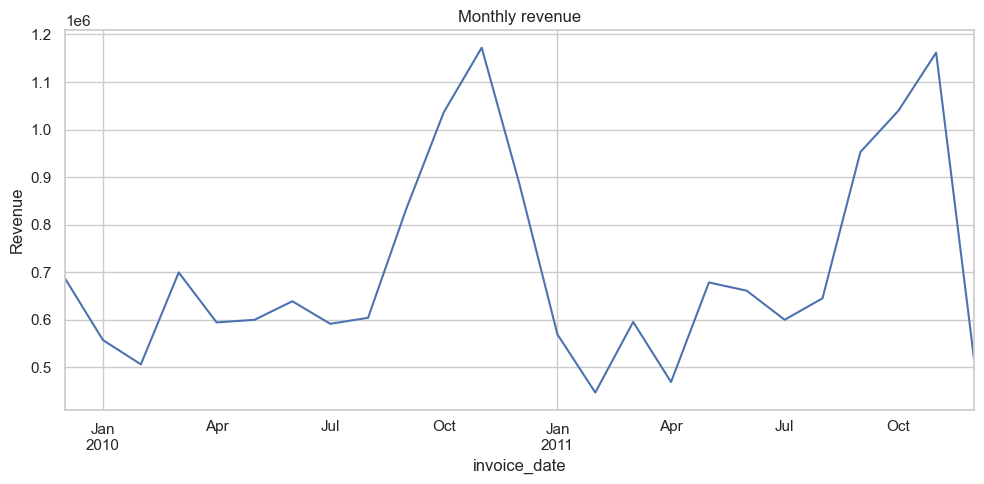

In [19]:
m = df.set_index('invoice_date').resample('M')['revenue'].sum()
m.plot(title='Monthly revenue'); plt.ylabel('Revenue'); plt.tight_layout()
plt.savefig('../reports/figures/monthly_revenue.png', dpi=120)

## Top countries

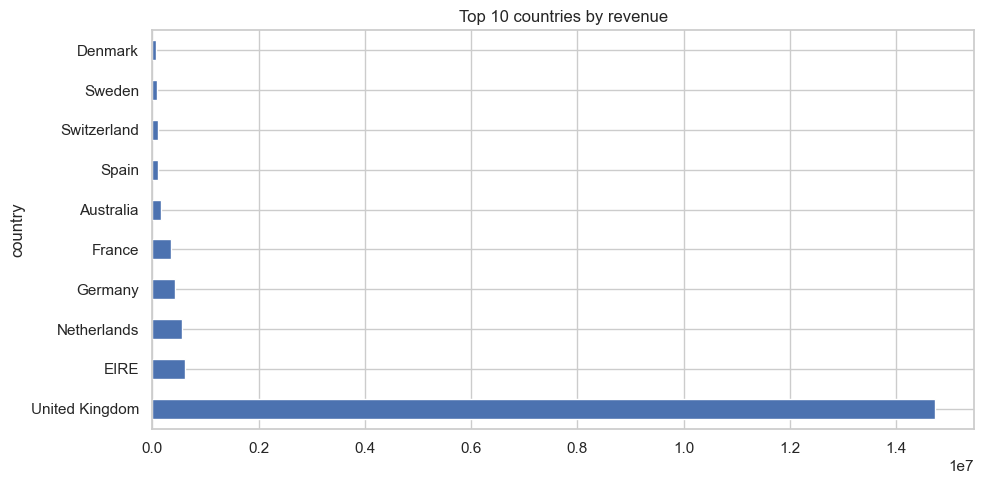

In [20]:
(df.groupby('country')['revenue'].sum().sort_values(ascending=False)
   .head(10).plot.barh(title='Top 10 countries by revenue'))
plt.tight_layout()

> **Next:** `02_churn_retention.ipynb`